In [3]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


# Sigmoid Function

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


# Gradient Calculation

def calculate_gradient(theta, X, y):
    m = y.size
    return (X.T @ (sigmoid(X @ theta) - y)) / m


# Gradient Descent

def gradient_descent(X, y, alpha=0.1, num_iter=1000, tol=1e-7):
    # Add bias column
    X_b = np.c_[np.ones((X.shape[0], 1)), X]

    # Initialize theta
    theta = np.zeros(X_b.shape[1])

    for i in range(num_iter):
        grad = calculate_gradient(theta, X_b, y)
        theta = theta - alpha * grad

        # Convergence check
        if np.linalg.norm(grad) < tol:
            break

    return theta


# Prediction Probability

def predict_proba(X, theta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return sigmoid(X_b @ theta)


# Prediction (0 or 1)

def predict(X, theta, threshold=0.5):
    return (predict_proba(X, theta) >= threshold).astype(int)


# Load Dataset

X, y = load_breast_cancer(return_X_y=True)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature Scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model

theta_hat = gradient_descent(X_train_scaled, y_train, alpha=0.1)

# Predictions

y_pred_train = predict(X_train_scaled, theta_hat)
y_pred_test = predict(X_test_scaled, theta_hat)

# Accuracy

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.9868131868131869
Test Accuracy: 0.9824561403508771


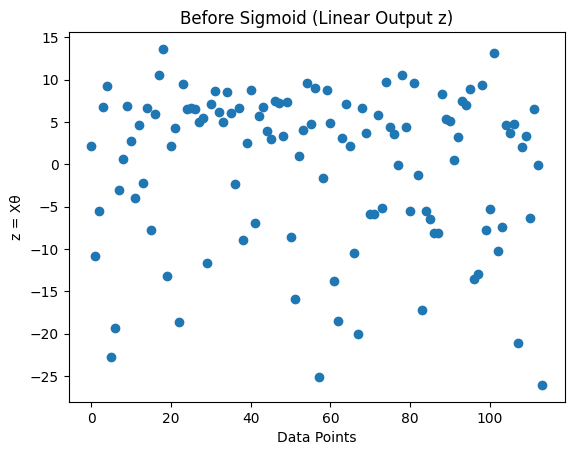

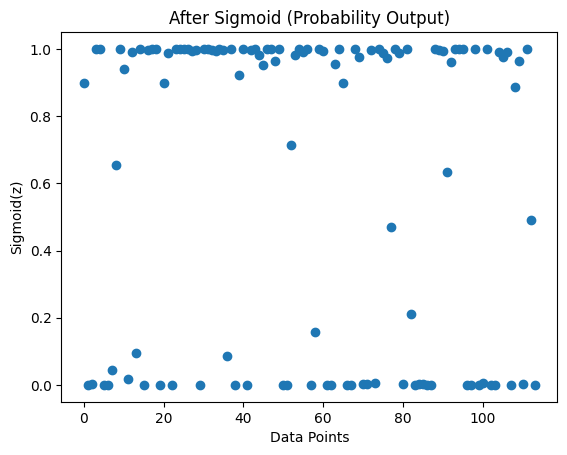

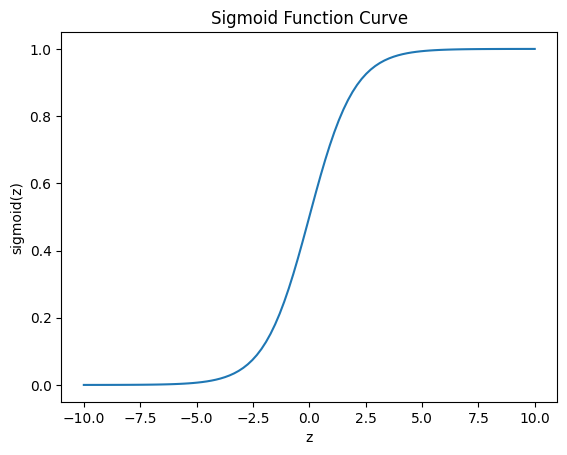

In [4]:
import matplotlib.pyplot as plt


X_b_test = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]
z_values = X_b_test @ theta_hat   # linear output

prob_values = sigmoid(z_values)


plt.figure()
plt.scatter(range(len(z_values)), z_values)
plt.title("Before Sigmoid (Linear Output z)")
plt.xlabel("Data Points")
plt.ylabel("z = Xθ")
plt.show()


plt.figure()
plt.scatter(range(len(prob_values)), prob_values)
plt.title("After Sigmoid (Probability Output)")
plt.xlabel("Data Points")
plt.ylabel("Sigmoid(z)")
plt.show()


z_range = np.linspace(-10, 10, 100)
sigmoid_curve = sigmoid(z_range)

plt.figure()
plt.plot(z_range, sigmoid_curve)
plt.title("Sigmoid Function Curve")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.show()